## Employee Salary Prediction And Analytics Platform

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv("salary_prediction_data.csv")
data.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [2]:
print(" ====== Dataset Inspection ======= ")
print("\n Shape of Dataset")
print(data.shape)

print("\n Dataset Columns Name : ")
print(data.columns)

print("\n Dataset Information :")
data.info()

print("\n Check Missing Values ")
print(data.isnull().sum())

print("\n Duplicated Data ")
print(data.duplicated().sum())

 ====== Dataset Inspection ======= 

 Shape of Dataset
(1000, 7)

 Dataset Columns Name : 
Index(['Education', 'Experience', 'Location', 'Job_Title', 'Age', 'Gender',
       'Salary'],
      dtype='str')

 Dataset Information :
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   str    
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   str    
 3   Job_Title   1000 non-null   str    
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   str    
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 79.8 KB

 Check Missing Values 
Education     0
Experience    0
Location      0
Job_Title     0
Age           0
Gender        0
Salary        0
dtype: int64

 Duplicated Data 
0


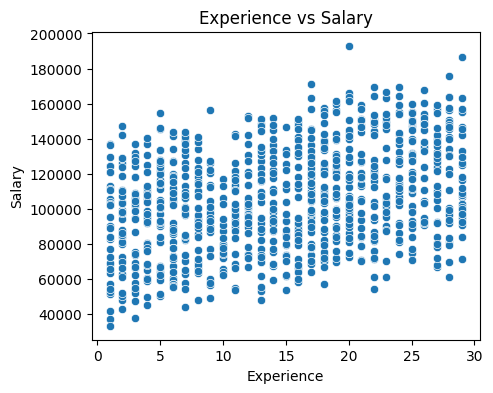

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,4))
sns.scatterplot(data=data, x = "Experience", y = "Salary")
plt.title("Experience vs Salary")
plt.show()

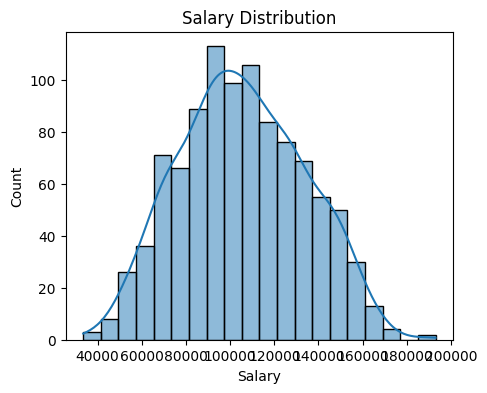

In [21]:
plt.figure(figsize=(5,4))
sns.histplot(data = data , x ="Salary", kde = True)
plt.title("Salary Distribution")
plt.show()

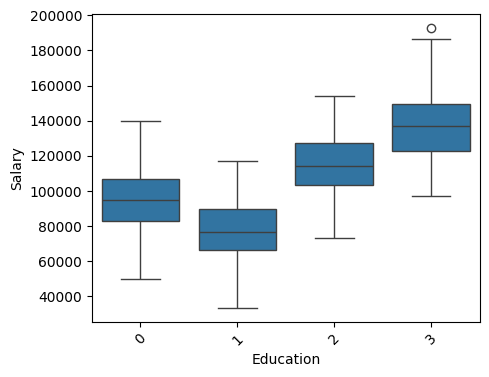

In [22]:
plt.figure(figsize=(5,4))
sns.boxplot(data = data , x = "Education", y= "Salary")
plt.xticks(rotation = 45)
plt.show()

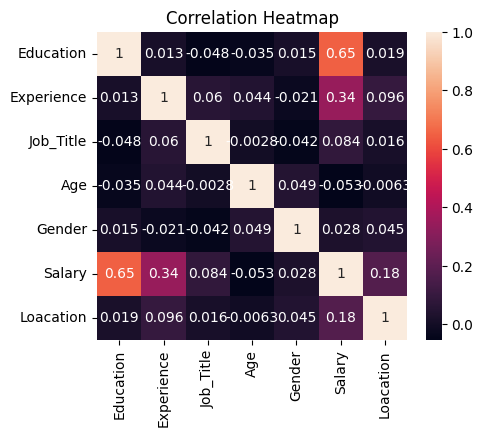

In [23]:
plt.figure(figsize=(5,4))
numeric_data = data.select_dtypes(include = np.number)
sns.heatmap(numeric_data.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
X = data.drop(
    "Salary",
    axis=1
)
y = data["Salary"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [27]:
numeric_features = [
    "Age",
    "Experience"
]

categorical_features = [
    "Education",
    "Job_Title",
    "Location",
    "Gender"
]

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Education','Experience','Location',...,'Age','Gender','Loacation']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [30]:
linear_pred = linear_pipeline.predict(X_test)

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Education','Experience','Location',...,'Age','Gender','Loacation']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [32]:
rf_pred = rf_pipeline.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    rf_pred
)

print("MAE:", mae)

MAE: 9321.385620228491


In [34]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(
    y_test,
    rf_pred
)

print("RMSE:", rmse)

RMSE: 11453.22027960779


In [35]:
from sklearn.metrics import r2_score 

r2 = r2_score(
    y_test,
    rf_pred
)

print("R²:", r2)

R²: 0.8393484524275526


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =====================================
# Linear Regression Evaluation
# =====================================

linear_pred = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)


# =====================================
# Random Forest Evaluation
# =====================================

rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)


# =====================================
# Print Results
# =====================================

print("===== Linear Regression =====")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

print("\n===== Random Forest =====")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

===== Linear Regression =====
MAE : 8157.898478643166
RMSE: 10295.449366636143
R2  : 0.8701863681609703

===== Random Forest =====
MAE : 9321.385620228491
RMSE: 11453.22027960779
R2  : 0.8393484524275526


In [38]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

print("===== Model Comparison =====")
print(results)

===== Model Comparison =====
               Model          MAE          RMSE        R2
0  Linear Regression  8157.898479  10295.449367  0.870186
1      Random Forest  9321.385620  11453.220280  0.839348


In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print("Mean R²:", scores.mean())

[0.83923905 0.86287728 0.8474542  0.81931506 0.81039802]
Mean R²: 0.83585672214327


In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [
        100,
        200
    ],
    "model__max_depth": [
        None,
        10,
        20
    ],
    "model__min_samples_split": [
        2,
        5
    ]
}

In [41]:
grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int,

In [42]:
print(grid.best_params_)

{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [43]:
print(grid.best_score_)

0.842698435508533


In [44]:
best_model = grid.best_estimator_

In [45]:
final_pred = best_model.predict(
    X_test
)

In [46]:
final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = root_mean_squared_error(
    y_test,
    final_pred
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R²:", final_r2)

MAE: 9072.102797155685
RMSE: 11147.96426608134
R²: 0.847797837752523


In [47]:
import joblib

joblib.dump(
    best_model,
    "employee_salary_model.joblib"
)

['employee_salary_model.joblib']

In [48]:
loaded_model = joblib.load(
    "employee_salary_model.joblib"
)

In [51]:
new_employee = pd.DataFrame({
    "Age": [28],
    "Experience": [5],
    "Education": ["Bachelor"],
    "Job_Title": ["Analyst"],
    "Gender": ["Male"],
    "Location": ["Mumbai"]
})

In [52]:
salary_prediction = loaded_model.predict(
    new_employee
)

print(
    "Predicted Salary:",
    salary_prediction[0]
)

Predicted Salary: 72158.31004570759


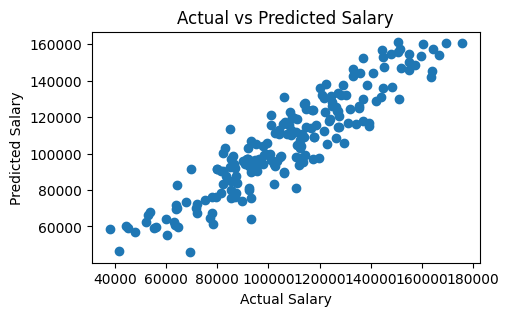

In [54]:
plt.figure(figsize=(5,3))
plt.scatter(
    y_test,
    final_pred
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title(
    "Actual vs Predicted Salary"
)

plt.show()